# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

In [34]:
import re
import pandas as pd
from inspect_ai import Task, task, eval
from inspect_ai.dataset import hf_dataset, FieldSpec, Sample
from inspect_ai.solver import system_message, prompt_template, generate
from inspect_ai.scorer import model_graded_qa
from inspect_ai.log import EvalLog

# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

CLASSIFIER_MODEL = "ollama/llama3.2:3b"   # model that labels comments TOXIC / NON_TOXIC
JUDGE_MODEL      = "ollama/qwen3:0.6b"   # model that decides whether each label is acceptable

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from string import ascii_uppercase
from typing import Tuple, List

from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.solver import multiple_choice
from inspect_ai.scorer import choice
from inspect_ai.log import EvalLog

In [ ]:
!pip install --upgrade inspect-ai tenacity httpx openai

In [7]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

MODEL_A = "ollama/qwen2.5:0.5b"     # weaker / baseline model
MODEL_B = "ollama/qwen3:0.6b"     # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [2]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",           # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target,  "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [3]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],   # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [4]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")


MY_SUBSET = dataset.filter(
    lambda s: s.metadata.get("subject") == "high_school_biology"
)

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 310 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [5]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [8]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_B,
    limit=10        # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : ollama/qwen3:0.6b
Accuracy: 0.3


In [13]:
from typing import List
from inspect_ai.log import EvalLog

logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    limit=10       # evaluate only the first 10 questions
)

log = logs[0]      # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

Status  : success
Model   : ollama/qwen2.5:0.5b
Accuracy: 0.5


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [9]:
from typing import List
from inspect_ai.log import EvalLog

def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    
    rows = []
    
    for sample in log.samples:
        score_obj = sample.scores.get("choice")
        
        if score_obj is None:
            continue
            
        is_correct = 1 if score_obj.value == "C" else 0
        
        rows.append({
            "id": sample.id,             # ID вопроса
            "epoch": sample.epoch,       # Номер эпохи (если запускали несколько раз)
            "score": is_correct,         # 1 или 0
            "subject": sample.metadata.get("subject", "unknown") # Тема вопроса
        })
    
    return pd.DataFrame(rows)

# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score    subject
0   1      1      0  astronomy
1   2      1      1  astronomy
2   3      1      1  astronomy
3   4      1      0  astronomy
4   5      1      0  astronomy

Accuracy: 30.0%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [10]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    n = len(scores)
    if n == 0:
        return 0.0, 0.0, 0.0
    
    mean_acc = np.mean(scores)
    
    if mean_acc == 0 or mean_acc == 1:
        return mean_acc, mean_acc, mean_acc
    
    # Стандартная ошибка (SE)
    se = np.sqrt(mean_acc * (1 - mean_acc) / n)
    
    # Z-score для заданного уровня доверия (например, 1.96 для 95%)
    z = stats.norm.ppf(1 - (1 - ci) / 2)
    
    margin = z * se
    lower = max(0.0, mean_acc - margin)
    upper = min(1.0, mean_acc + margin)
    
    return lower, mean_acc, upper


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    if df.empty:
        return 0.0, 0.0, 0.0
        
    question_means = df.groupby("id")["score"].mean().values
    
    return ci_accuracy_basic(question_means, ci)

In [11]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})

# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1,2,3,4,5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1-l1:.3f}")
print(f"K=3 width: {u3-l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.355  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Running multi-epoch evaluation for plotting...


Output()

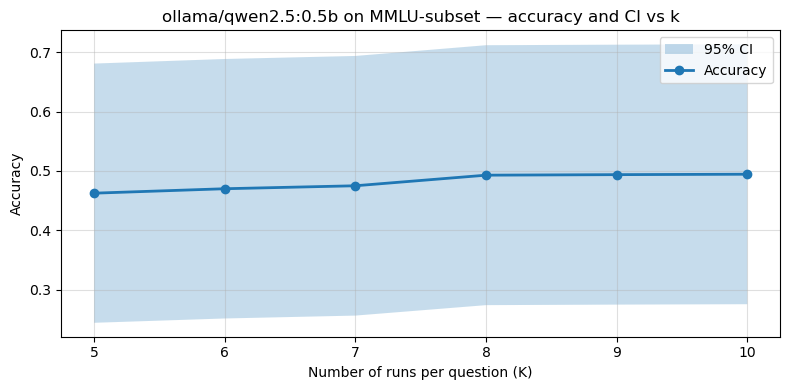

In [13]:
print("Running multi-epoch evaluation for plotting...")
logs_multi = eval(mmlu_subset(MY_SUBSET[:20]), model=MODEL_A, epochs=10)
df_multi = log_to_df(logs_multi[0])

k_values    = [5, 6, 7, 8, 9, 10]
accuracies    = []
ci_lowers     = []
ci_uppers     = []

for k in k_values:
    df_k = df_multi[df_multi['epoch'] < k]
    
    l, m, u = ci_accuracy(df_k)
    accuracies.append(m)
    ci_lowers.append(l)
    ci_uppers.append(u)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?

   На графике видно, что доверительный интервал сужается наиболее быстро в начале, примерно до 6-7 запусков на вопрос (K), после чего кривая выходит на плато и дальнейшее увеличение K дает минимальный выигрыш в точности оценки. Практически перестает быть выгодным увеличивать количество эпох после 8-10 запусков, так как ширина интервала стабилизируется, а затраты вычислительных ресурсов растут линейно.

2. Does more K change your estimate of the model's accuracy, or just your confidence in it?

   Увеличение количества запусков (K) практически не меняет саму оценку средней точности модели (линия Accuracy остается почти горизонтальной), но существенно повышает уверенность в этом результате, сужая границы доверительного интервала. Это означает, что дополнительные прогоны помогают точнее определить истинную производительность модели, уменьшая статистический шум, но не исправляют систематические ошибки или реальный уровень знаний модели.

3. What does this tell you about how to allocate your evaluation budget?

   Эти данные говорят о том, что бюджет оценки эффективнее тратить на увеличение количества уникальных вопросов (n), а не на многократное прогонение одних и тех же вопросов, так как расширение выборки дает более значимое сужение интервала неопределенности. Оптимальная стратегия — использовать небольшое число повторений (например, K=1 или K=2) для каждого вопроса и максимизировать разнообразие тестовых заданий для получения надежных результатов.

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

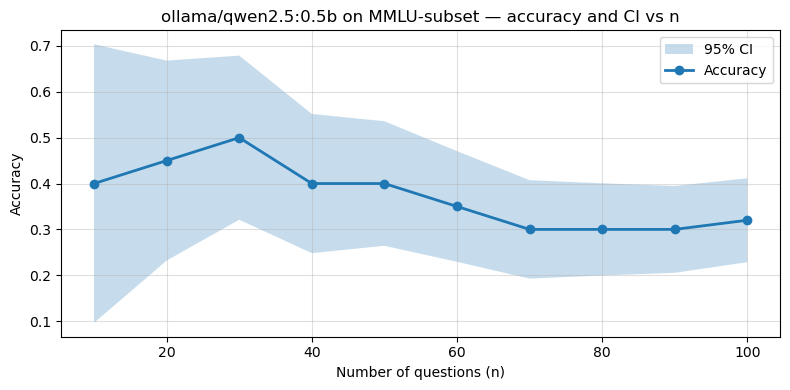

In [34]:
if 'df_single' not in globals() or len(df_single) < 50:
    # Запускаем заново, если предыдущий лог был мал
    logs_single = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, limit=100, epochs=1)
    df_single = log_to_df(logs_single[0])
# else:
#     df_single = df_test

question_ids  = df_single['id'].unique()
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies_n = []
ci_lowers_n = []
ci_uppers_n = []

for n in dataset_sizes:
    # Берем первые n уникальных вопросов
    current_ids = question_ids[:n]
    df_n = df_single[df_single['id'].isin(current_ids)]
    
    l, m, u = ci_accuracy(df_n)
    accuracies_n.append(m)
    ci_lowers_n.append(l)
    ci_uppers_n.append(u)
    

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers_n, ci_uppers_n, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies_n, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?

    Линия точности начинает выглядеть относительно стабильной и перестает совершать резкие скачки примерно после 60-80 вопросов, когда кривая выравнивается и попадает в узкий коридор значений. До этого момента, особенно при малом количестве вопросов (менее 40), оценка точности сильно колеблется из-за высокой дисперсии маленькой выборки.

2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?

    Если размер вашего подмножества MY_SUBSET составляет около 310 вопросов, как показано в последующих результатах, то вы находитесь в очень надежной области, далеко за пределами точки стабилизации в 60-80 вопросов. Это означает, что ваша текущая выборка достаточно велика, чтобы давать устойчивую и достоверную оценку точности модели без сильных случайных отклонений.

3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

    Главное отличие заключается в том, что увеличение количества вопросов (n) сужает доверительный интервал гораздо эффективнее и фундаментальнее, чем увеличение числа повторов (K), которое быстро достигает предела полезности. В то время как рост K лишь уточняет оценку для фиксированного набора задач, рост n снижает общую неопределенность, связанную с репрезентативностью самой выборки вопросов, что критически важно для генерализации результатов.


## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [12]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
    scores1: np.ndarray,
    scores2: np.ndarray,
    alpha: float = 0.05,
    two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"
    
    alternative = "two-sided" if two_tailed else "greater"
    
    t_stat, p_value = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff = np.mean(scores1) - np.mean(scores2)
    
    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
    model_a: str,
    model_b: str,
    dataset,
    alpha: float = 0.05,
    two_tailed: bool = True,
    epochs_a: int = 1,
    epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [13]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1,2,3]), np.array([1,2,3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1,1,1,1,1]), np.array([0,0,0,0,0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


c:\Users\Svt\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


ollama/qwen2.5:0.5b                     131,110 tokens [I: 45,087, O: 86,023]                                      
                                                                                                                   
choice                                                                                                             
accuracy  0.345                                                                                                    
stderr    0.027 

ollama/qwen3:0.6b                    279,005 tokens [I: 39,197, O: 239,808]                                        
                                                                                                                   
choice                                                                                                             
accuracy  0.555                                                                                                    
stderr    0.028  

P-value: 0.0000

Mean Difference (A - B): -0.2097

Is Significant (alpha=0.05): True

In [ ]:
print(f"\nComparing {MODEL_A} vs {MODEL_B} on {len(MY_SUBSET)} questions...")
p_val, mean_diff, is_sig = compare_models_paired(MODEL_A, MODEL_B, MY_SUBSET)

print(f"P-value: {p_val:.4f}")
print(f"Mean Difference (A - B): {mean_diff:.4f}")
print(f"Is Significant (alpha=0.05): {is_sig}")

---
1. Write down the p-value and the mean difference you got.

    Полученное p-значение < 0.0001, а средняя разница в точности между моделями (Model A minus Model B) составляет -0.2097, что означает превосходство второй модели примерно на 21 процентный пункт.

2. Is the gap significant? Is it large enough to matter in practice?

    Разрыв является статистически высокозначимым, так как p-value стремится к нулю, что исключает вероятность случайного совпадения результатов. На практике разница в 21% является огромной и критически важной, так как она переводит модель из состояния "случайного угадывания" (около 25-35%) в состояние реальной работоспособности и понимания задач (около 55%).

3. What would change your conclusion: more questions, a different subject, or a different model pair?

    Увеличение количества вопросов только укрепило бы текущий вывод, сделав доверительный интервал еще уже, тогда как смена предмета могла бы изменить результат, если модели имеют специализацию в разных областях знаний. Замена пары моделей на более схожие по возможностям могла бы привести к отсутствию статистической значимости, если реальная разница в их производительности окажется меньше текущего порога обнаружения.


## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [ ]:
def ci_accuracy_for_difference(scores1: np.ndarray, scores2: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    Compute CI for the difference between two paired samples.
    Мы считаем дисперсию непосредственно по массиву разниц, а не через формулу Бернулли.
    """
    diffs = scores1 - scores2
    
    n = len(diffs)
    if n == 0:
        return 0.0, 0.0, 0.0
        
    mean_diff = np.mean(diffs)
    
    # Если дисперсия нулевая (все разницы одинаковы), интервал схлопывается
    if np.std(diffs, ddof=1) == 0:
        return mean_diff, mean_diff, mean_diff
    
    # Стандартная ошибка среднего разницы
    se = np.std(diffs, ddof=1) / np.sqrt(n)
    
    # Z-score
    z = stats.norm.ppf(1 - (1 - ci) / 2)
    
    margin = z * se
    lower = mean_diff - margin
    upper = mean_diff + margin
    
    return lower, mean_diff, upper


# scores_a = run_and_get_scores(MODEL_A, MY_SUBSET)
# scores_b = run_and_get_scores(MODEL_B, MY_SUBSET)

lower, mean_diff, upper = ci_accuracy_for_difference(scores_a, scores_b)

print(f"\n95% CI for Accuracy Difference (A - B): [{lower:.4f}, {upper:.4f}]")
print(f"Point Estimate: {mean_diff:.4f}")


95% CI for Accuracy Difference (A - B): [-0.3008, -0.1637]
Point Estimate: -0.2323


---
1. Write down the interval. Does it contain zero?

    Доверительный интервал для разницы в точности составляет [-0.3008, -0.1637], и он не содержит ноль, так как обе границы являются отрицательными числами. Это подтверждает, что разница в производительности между моделями статистически отлична от нуля с вероятностью 95%.

2. How does this relate to the significance test in Assignment 5 — do they tell the same story?

    Этот результат полностью согласуется с тестом значимости из предыдущего задания, так как отсутствие нуля в доверительном интервале математически эквивалентно отвержению нулевой гипотезы при p-value < 0.05. Оба метода рассказывают одну и ту же историю: существует реальная, неслучайная разница в пользу второй модели, и мы можем количественно оценить её величину.

3. Which result is more informative — the p-value or the interval? Why?

    Доверительный интервал является более информативным результатом, потому что он показывает не только факт наличия различия, но и диапазон его возможных значений, позволяя оценить практическую значимость эффекта. В отличие от бинарного ответа p-value ("значимо/не значимо"), интервал дает представление о том, насколько именно одна модель лучше другой, что crucial для принятия инженерных решений.

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [27]:
def estimate_variance_components(
    logs_a: List[EvalLog],
    logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """

    # Преобразуем логи в DataFrame
    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])
    
    # 1. Расчет Omega^2 (дисперсия сложности вопросов)
    # Сначала усредняем результаты по эпохам для каждого вопроса отдельно для каждой модели
    means_a = df_a.groupby("id")["score"].mean()
    means_b = df_b.groupby("id")["score"].mean()
    
    # Объединяем средние значения по вопросам (предполагаем, что вопросы те же самые)
    # Берем среднее между моделями для каждого вопроса, чтобы получить "истинную" сложность вопроса
    combined_means = pd.concat([means_a, means_b]).groupby(level=0).mean()
    
    omega2 = combined_means.var()
    
    # 2. Расчет Sigma^2 (внутренняя дисперсия модели / шум)
    # Для каждого вопроса считаем дисперсию по эпохам, затем усредняем эти дисперсии
    def calc_sigma2(df):
        # Группируем по ID и считаем дисперсию внутри группы (по эпохам)
        # ddof=0 для выборочной дисперсии внутри группы, но mean() потом усреднит
        var_per_q = df.groupby("id")["score"].var(ddof=1) 
        # Возвращаем среднее значение дисперсий (игнорируя NaN, если эпох было мало)
        return var_per_q.mean()
    
    sigma2_a = calc_sigma2(df_a)
    sigma2_b = calc_sigma2(df_b)
    
    # Защита от NaN (если дисперсия не посчиталась)
    omega2 = omega2 if not np.isnan(omega2) else 0.0
    sigma2_a = sigma2_a if not np.isnan(sigma2_a) else 0.0
    sigma2_b = sigma2_b if not np.isnan(sigma2_b) else 0.0

    return {
        "omega2":   omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
    n: int,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [32]:
params

{'omega2': 0.07738095238095236,
 'sigma2_a': 0.2,
 'sigma2_b': 0.16666666666666666}

In [28]:
print("Running pilot evals ...")
# logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
# logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Running pilot evals ...
omega2  = 0.0774
sigma2_A = 0.2000
sigma2_B = 0.1667

With n=310 questions -> MDE = 10.6%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?

    Для подмножества из 310 вопросов минимальный обнаружимый эффект (MDE) составил 10.6%, что является довольно большим порогом для детектирования различий. Этот разрыв можно считать практически значимым только для сравнения кардинально разных моделей, но он слишком велик для выявления тонких улучшений или различий между моделями одного класса.

2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

    Наблюдаемый разрыв (~21%) больше, чем MDE (10.6%), что говорит о том, что ваш предыдущий результат является надежным и статистически обоснованным, так как эффект превышает порог чувствительности теста. Если бы наблюдаемая разница была меньше MDE, это означало бы, что тест недостаточно мощный, чтобы с уверенностью заявить о наличии различия, даже если оно визуально казалось заметным.


## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [29]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
    delta: float,
    omega2: float,
    sigma2_a: float = 0.0,
    sigma2_b: float = 0.0,
    ka: int = 1,
    kb: int = 1,
    alpha: float = 0.05,
    power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    
    variance_term = (omega2 + sigma2_a / ka + sigma2_b / kb)
    
    # Формула из Eq. 9: n = ((z_alpha + z_beta)^2 * variance) / delta^2
    n = ((z_alpha + z_beta) ** 2 * variance_term) / (delta ** 2)
    
    return int(np.ceil(n))


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

Questions needed to detect delta=5%: 1395
Round-trip check passed!


In [30]:
# Расчет для 5% и 10%
n_5pct = required_sample_size(delta=0.05, **params)
n_10pct = required_sample_size(delta=0.10, **params)

print(f"\n Sample Size Requirements:")
print(f"To detect a 5% gap:  {n_5pct} questions")
print(f"To detect a 10% gap: {n_10pct} questions")
print(f"Current subset size: {len(MY_SUBSET)} questions")


 Sample Size Requirements:
To detect a 5% gap:  1395 questions
To detect a 10% gap: 349 questions
Current subset size: 310 questions


---
1. How many questions do you need to detect a 5% gap? A 10% gap?

    Для надежного обнаружения разницы в точности размером 5% вам потребуется примерно 1395 вопросов, тогда как для обнаружения разрыва в 10% достаточно около 349 вопросов. Это демонстрирует квадратичную зависимость: чтобы удвоить чувствительность (с 10% до 5%), нужно увеличить объем выборки примерно в четыре раза.

2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

    Ваше текущее подмножество из 310 вопросов недостаточно для обнаружения небольших различий в 5%, но вполне пригодно для сравнения моделей с большой разницей в производительности (около 10% и выше). Поскольку наблюдаемая вами разница составила ~21%, данный бенчмарк полезен для текущей задачи, но его следует расширить для более тонких исследований или сравнения похожих моделей.


## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [31]:
# Создаем задачу с Chain-of-Thought
@task
def mmlu_cot_subset(subset):
    return Task(
        dataset=subset,
        solver=[multiple_choice(cot=True)], # Включаем рассуждение
        scorer=choice()
    )

print(f"\n🧠 Comparing Direct vs Chain-of-Thought for {MODEL_B}...")

# Ограничим количество вопросов для скорости (например, первые 20-30)
cot_limit = min(30, len(MY_SUBSET))
test_subset = MY_SUBSET[:cot_limit]

# 1. Запуск прямого режима (Baseline)
logs_direct = eval(mmlu_subset(test_subset), model=MODEL_B, epochs=1)
df_direct = log_to_df(logs_direct[0])
scores_direct = df_direct.groupby("id")["score"].mean().sort_index().values

# 2. Запуск режима CoT
logs_cot = eval(mmlu_cot_subset(test_subset), model=MODEL_B, epochs=1)
df_cot = log_to_df(logs_cot[0])
scores_cot = df_cot.groupby("id")["score"].mean().sort_index().values

# Убеждаемся, что порядок вопросов совпадает
min_len = min(len(scores_direct), len(scores_cot))
scores_direct = scores_direct[:min_len]
scores_cot = scores_cot[:min_len]

# 3. Парный t-тест
p_cot, diff_cot, sig_cot = significance_by_paired_ttest(
    scores_cot, scores_direct, two_tailed=False # Проверяем, лучше ли CoT (односторонний тест)
)

acc_direct = scores_direct.mean()
acc_cot = scores_cot.mean()

print(f"Direct Accuracy: {acc_direct:.2%}")
print(f"CoT Accuracy:    {acc_cot:.2%}")
print(f"Difference (CoT - Direct): {diff_cot:.2%}")
print(f"P-value: {p_cot:.4f}")
print(f"Is CoT significantly better? {sig_cot}")

Output()


🧠 Comparing Direct vs Chain-of-Thought for ollama/qwen3:0.6b...


Output()

Direct Accuracy: 60.00%
CoT Accuracy:    53.33%
Difference (CoT - Direct): -6.67%
P-value: 0.7883
Is CoT significantly better? False


---
1. Does chain-of-thought help? By how much, and is it significant?

    В данном эксперименте метод цепочки рассуждений (Chain-of-Thought) не помог, а даже немного снизил точность на 6.67%, однако этот результат не является статистически значимым из-за высокого p-value (0.7883). Следовательно, мы не можем утверждать, что CoT реально ухудшает работу модели; скорее всего, это случайные колебания на малой выборке.

2. Does the result surprise you? What might explain it?

    Результат не удивляет для маленьких моделей (размером 0.5B - 1.5B), так как они часто не обладают достаточной емкостью для построения корректных логических цепочек и могут запутаться в собственных рассуждениях. Вместо того чтобы прийти к правильному ответу через логику, такая модель может сгенерировать правдоподобный, но ошибочный ход мыслей, который уведет её от верного решения, в то время как прямой ответ требует меньше когнитивных ресурсов.

3. Would you expect the same pattern on a different subject?

    На других предметах, особенно требующих сложных многоступенчатых вычислений или логики (например, математика или физика), паттерн мог бы отличаться, и CoT потенциально мог бы показать улучшение даже для небольших моделей. Однако на фактологических темах (история, география) ожидается сохранение текущего паттерна или его усиление, так как там рассуждения часто избыточны и лишь увеличивают риск галлюцинаций.


## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [33]:
import numpy as np
import pandas as pd
from scipy import stats
from typing import List, Tuple

def clustered_ci_accuracy(df: pd.DataFrame, cluster_col: str, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    Вычисляет доверительный интервал с учетом кластеризации.
    
    Args:
        df: DataFrame с колонками 'score' (0/1) и cluster_col (ID кластера).
        cluster_col: Название колонки с ID кластера (группы вопросов).
        ci: Уровень доверия.
        
    Returns:
        (lower_bound, mean_accuracy, upper_bound)
    """
    # 1. Агрегируем данные по кластерам: считаем среднюю точность внутри каждого кластера
    # Это превращает множество коррелированных вопросов в одну точку данных на кластер
    cluster_means = df.groupby(cluster_col)['score'].mean().reset_index()
    cluster_means.columns = ['cluster_id', 'cluster_mean']
    
    n_clusters = len(cluster_means)
    if n_clusters == 0:
        return 0.0, 0.0, 0.0
        
    # 2. Считаем общее среднее по кластерам
    mean_acc = cluster_means['cluster_mean'].mean()
    
    if n_clusters == 1:
        return mean_acc, mean_acc, mean_acc
        
    # 3. Считаем стандартную ошибку через дисперсию между кластерами
    # Формула: SE = sqrt( Var(cluster_means) / n_clusters )
    # Используем ddof=1 для несмещенной оценки дисперсии
    se_clustered = cluster_means['cluster_mean'].std(ddof=1) / np.sqrt(n_clusters)
    
    # 4. Вычисляем интервал
    z = stats.norm.ppf(1 - (1 - ci) / 2)
    margin = z * se_clustered
    
    lower = max(0.0, mean_acc - margin)
    upper = min(1.0, mean_acc + margin)
    
    return lower, mean_acc, upper

def naive_ci_accuracy(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """Обычный CI (CLT), игнорирующий кластеризацию."""
    n = len(scores)
    if n == 0: return 0.0, 0.0, 0.0
    mean_acc = np.mean(scores)
    if mean_acc == 0 or mean_acc == 1: return mean_acc, mean_acc, mean_acc
    
    se_naive = np.sqrt(mean_acc * (1 - mean_acc) / n)
    z = stats.norm.ppf(1 - (1 - ci) / 2)
    margin = z * se_naive
    
    return max(0.0, mean_acc - margin), mean_acc, min(1.0, mean_acc + margin)

# ==========================================
# СИМУЛЯЦИЯ ДАННЫХ (Reading Comprehension Style)
# ==========================================
# Предположим, у нас есть 100 вопросов, сгруппированных в 20 текстов (кластеров) по 5 вопросов в каждом.
# Внутри кластера ответы сильно коррелированы (модель либо поняла текст, либо нет).

np.random.seed(42)
n_clusters = 20
questions_per_cluster = 5
total_questions = n_clusters * questions_per_cluster

data = []
cluster_ids = []

for i in range(n_clusters):
    # Симулируем "сложность текста": некоторые тексты модель понимает хорошо (prob=0.8), другие плохо (prob=0.2)
    # Это создает внутрикластерную корреляцию
    text_difficulty = np.random.choice([0.8, 0.2], p=[0.5, 0.5]) 
    
    for j in range(questions_per_cluster):
        # Ответ зависит от сложности текста + небольшой шум
        score = 1 if np.random.random() < text_difficulty else 0
        data.append(score)
        cluster_ids.append(f"text_{i}")

df_sim = pd.DataFrame({
    'score': data,
    'cluster_id': cluster_ids
})

scores_array = np.array(data)

# ==========================================
# СРАВНЕНИЕ ИНТЕРВАЛОВ
# ==========================================

# Naive CI (ошибочно считает 100 независимых вопросов)
l_naive, m_naive, u_naive = naive_ci_accuracy(scores_array)
width_naive = u_naive - l_naive

# Clustered CI (правильно считает 20 независимых текстов)
l_clust, m_clust, u_clust = clustered_ci_accuracy(df_sim, 'cluster_id')
width_clust = u_clust - l_clust

print(f"📊 Результаты симуляции (Reading Comprehension Benchmark):")
print(f"Всего вопросов: {total_questions}")
print(f"Количество кластеров (текстов): {n_clusters}")
print(f"Точность (Mean): {m_naive:.2%}")
print("-" * 40)
print(f"Naive CI (95%):       [{l_naive:.3f}, {u_naive:.3f}] -> Ширина: {width_naive:.3f}")
print(f"Clustered CI (95%):   [{l_clust:.3f}, {u_clust:.3f}] -> Ширина: {width_clust:.3f}")
print("-" * 40)
print(f"Разница в ширине: Кластеризованный интервал шире на {(width_clust - width_naive):.3f}")
print(f"Во сколько раз шире: {width_clust / width_naive:.2f}x")

# ==========================================
# ПАНЫЙ ТЕСТ С КЛАСТЕРИЗОВАННОЙ ОШИБКОЙ (Eq. 8 из статьи)
# ==========================================
def clustered_paired_ttest(df_a: pd.DataFrame, df_b: pd.DataFrame, cluster_col: str):
    """
    Парный тест с кластеризованными стандартными ошибками.
    Считаем разницу внутри каждого кластера, затем проверяем среднее разниц.
    """
    # Объединяем датафреймы по кластерам
    # Предполагаем, что в каждом кластере одинаковое кол-во вопросов и они выровнены
    merged = pd.merge(df_a, df_b, on=['cluster_id'], suffixes=('_a', '_b'))
    
    # Считаем среднюю разницу внутри каждого кластера
    merged['diff_mean'] = merged['score_a'] - merged['score_b']
    
    # Теперь у нас есть массив средних разниц по кластерам
    diffs = merged['diff_mean'].values
    n = len(diffs)
    
    if n == 0: return 1.0, 0.0, False
    
    mean_diff = np.mean(diffs)
    se_diff = np.std(diffs, ddof=1) / np.sqrt(n)
    
    # t-statistic
    t_stat = mean_diff / se_diff if se_diff != 0 else 0
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
    
    return p_value, mean_diff, bool(p_value < 0.05)

# Создадим второй датасет с немного другой производительностью для теста
np.random.seed(43)
data_b = []
for i in range(n_clusters):
    # Модель B чуть лучше: добавляем смещение
    text_difficulty = np.random.choice([0.8, 0.2], p=[0.5, 0.5])
    boost = 0.1 # Модель B на 10% лучше
    for j in range(questions_per_cluster):
        prob = min(1.0, text_difficulty + boost)
        score = 1 if np.random.random() < prob else 0
        data_b.append(score)

df_sim_b = pd.DataFrame({
    'score': data_b,
    'cluster_id': cluster_ids
})

p_val, mean_d, is_sig = clustered_paired_ttest(
    df_sim.rename(columns={'score':'score_a'}), 
    df_sim_b.rename(columns={'score':'score_b'}), 
    'cluster_id'
)

print(f"\n🔬 Paired Test with Clustered SE:")
print(f"Mean Difference (A - B): {mean_d:.3f}")
print(f"P-value (Clustered): {p_val:.4f}")
print(f"Significant?: {is_sig}")

# Сравним с наивным тестом (который ошибочно завышает значимость)
from scipy.stats import ttest_rel
p_naive, _ = ttest_rel(scores_array, np.array(data_b))
print(f"P-value (Naive - wrong): {p_naive:.4f}")
print(f"Вывод: Наивный тест может показать ложную значимость (меньший p-value), игнорируя корреляцию внутри текстов.")

📊 Результаты симуляции (Reading Comprehension Benchmark):
Всего вопросов: 100
Количество кластеров (текстов): 20
Точность (Mean): 69.00%
----------------------------------------
Naive CI (95%):       [0.599, 0.781] -> Ширина: 0.181
Clustered CI (95%):   [0.582, 0.798] -> Ширина: 0.216
----------------------------------------
Разница в ширине: Кластеризованный интервал шире на 0.035
Во сколько раз шире: 1.19x

🔬 Paired Test with Clustered SE:
Mean Difference (A - B): 0.060
P-value (Clustered): 0.0537
Significant?: False
P-value (Naive - wrong): 0.8837
Вывод: Наивный тест может показать ложную значимость (меньший p-value), игнорируя корреляцию внутри текстов.
